In [41]:
import numpy as np
import pandas as pd
import hdbscan

In [42]:
df = pd.read_csv(r"dataset\preprocessing\prePro-news_filtered.csv")
embeddings = np.load(r"dataset\notFineTuned\embeddings\unbalanced_episode_embeddings.npy")
df['timestamp'] = pd.to_datetime(df['published_date'])

print("Embeddings Shape:", embeddings.shape)

Embeddings Shape: (5120, 385)


## Episode Discovery using HDBSCAN

In [43]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=8,
    min_samples=3,
    metric='euclidean'
)

labels = clusterer.fit_predict(embeddings)

print("Unique Clusters:", np.unique(labels))

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Unique Clusters: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46
 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61]


In [44]:
df['episode'] = labels

print(df['episode'].value_counts())

-1     3831
 36     122
 60      83
 46      70
 59      50
       ... 
 2        8
 29       8
 10       8
 35       8
 13       8
Name: episode, Length: 63, dtype: int64


## Dimentionality Reduction

In [45]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

embedding_2d = reducer.fit_transform(embeddings)

print("UMAP Shape:", embedding_2d.shape)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP Shape: (5120, 2)


## Episode cluster visualization

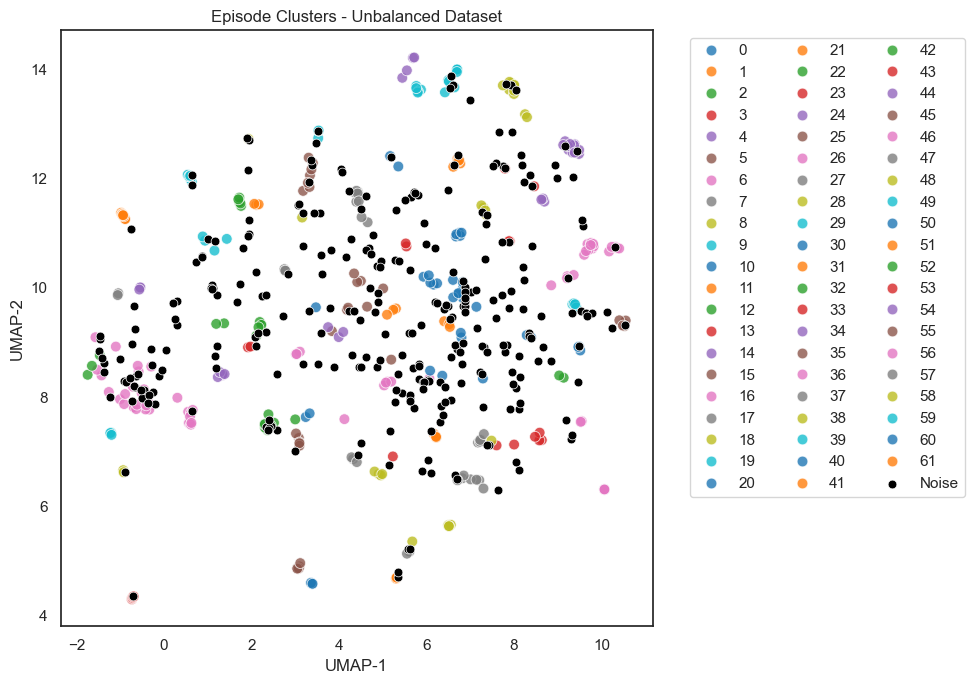

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))
plt.style.use('default')
sns.set_theme(style="white", palette="deep")

cluster_idx = np.where(labels != -1)[0]
cluster_sample = np.random.choice(cluster_idx, size=350, replace=False)

noise_idx = np.where(labels == -1)[0]
noise_sample = np.random.choice(noise_idx, size=min(300, len(noise_idx)), replace=False)

final_idx = np.concatenate([cluster_sample, noise_sample])

sns.scatterplot(
    x=embedding_2d[cluster_sample, 0],
    y=embedding_2d[cluster_sample, 1],
    hue=labels[cluster_sample],
    palette="tab10",
    s=60,
    alpha=0.8,
    legend=True
)

sns.scatterplot(
    x=embedding_2d[noise_sample, 0],
    y=embedding_2d[noise_sample, 1],
    color="black",
    s=40,
    label="Noise"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    ncol= 3
)

plt.title("Episode Clusters - Unbalanced Dataset")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.tight_layout()
plt.show()

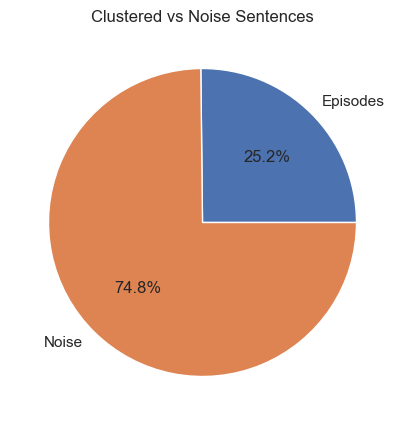

In [47]:
noise = np.sum(labels == -1)
clustered = np.sum(labels != -1)

plt.figure(figsize=(5,5))
plt.pie(
    [clustered, noise],
    labels=["Episodes", "Noise"],
    autopct='%1.1f%%'
)
plt.title("Clustered vs Noise Sentences")
plt.show()

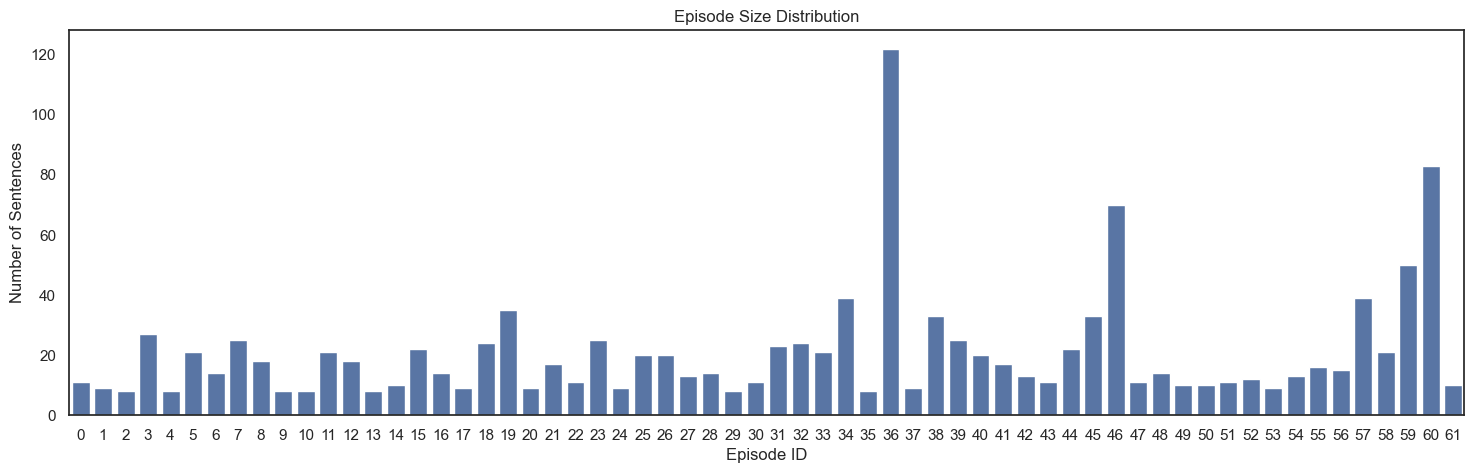

In [48]:
episode_sizes = df[df['episode'] != -1]['episode'].value_counts()

plt.figure(figsize=(18,5))
sns.barplot(
    x=episode_sizes.index,
    y=episode_sizes.values
)

plt.title("Episode Size Distribution")
plt.xlabel("Episode ID")
plt.ylabel("Number of Sentences")
plt.show()

In [49]:
t0 = df['timestamp'].min()
df['t'] = (df['timestamp'] - t0).dt.days
df['t_norm'] = df['t'] / df['t'].max()

In [50]:
episode_time_spread = df[df['episode'] != -1].groupby('episode')['t_norm'].std()

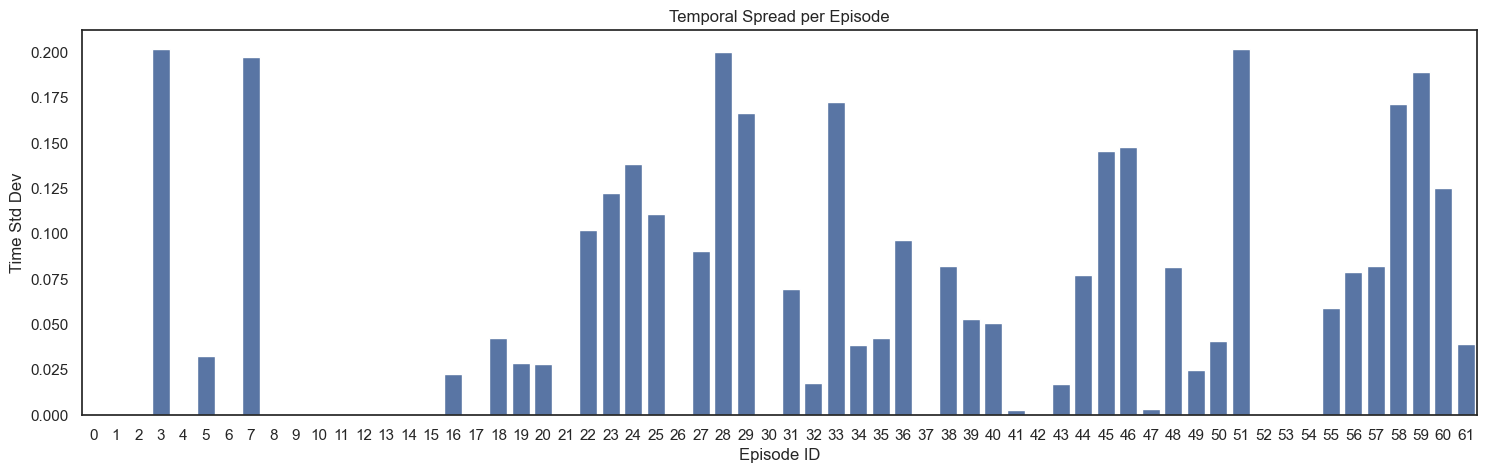

In [51]:
plt.figure(figsize=(18,5))
sns.barplot(
    x=episode_time_spread.index,
    y=episode_time_spread.values
)

plt.title("Temporal Spread per Episode")
plt.xlabel("Episode ID")
plt.ylabel("Time Std Dev")
plt.show()

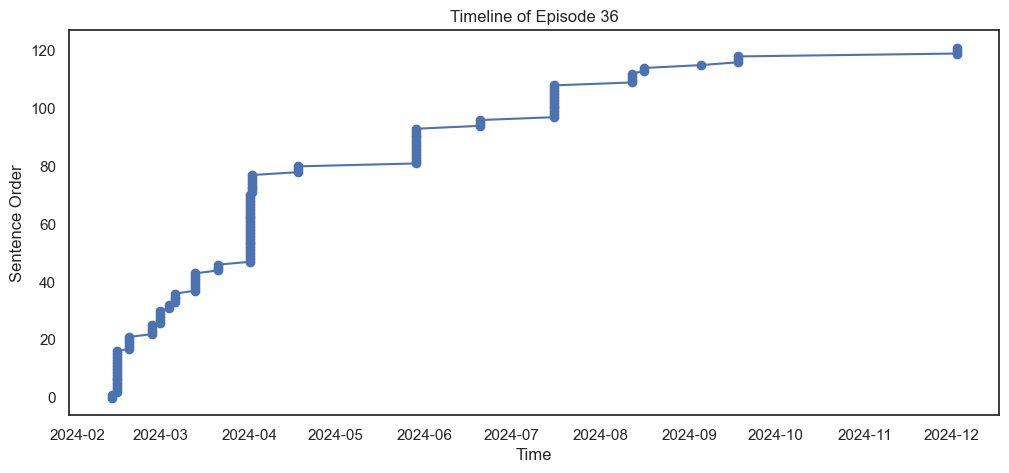

In [52]:
episode_id = 36

episode_df = df[df['episode'] == episode_id].sort_values('timestamp')

plt.figure(figsize=(12,5))
plt.plot(episode_df['timestamp'], range(len(episode_df)), marker='o')

plt.title(f"Timeline of Episode {episode_id}")
plt.xlabel("Time")
plt.ylabel("Sentence Order")
plt.show()

## Semantic Coherence Check

In [53]:
sample = df[df['episode'] == episode_id]['sentence'].sample(10, random_state=42)

for s in sample:
    print("-", s)

- Former Traverse City coffee shop owner Edward Witkowski was sentenced to serve at least four years in prison for "deviant, illegal, inappropriate and highly unusual" criminal behaviour that involved secretly videotaping women using his shop's restroom.
- The detective said the video shows Selleny recording himself as he committed a sex act in her home.
- “Evidence found on the device depicted the victim in various stages of dress, undress and full nudity,” police said in the March 29 news release.
- While in Reibel’s home, the woman and her friend discovered hidden cameras in the living room and bedroom where the man had instructed them to sleep, two of which were disguised to look like digital alarm clocks, according to the affidavit.
- The 30-year-old teacher who discovered a camera under her table, identified in court documents as the first victim, was in her third trimester of pregnancy at the time of Wang’s offence against her.
- Then report the violation to the rental platform,

In [54]:
episode_time = df[df['episode'] == episode_id]['timestamp']

print("Start:", episode_time.min())
print("End:", episode_time.max())

Start: 2024-02-13 00:00:00
End: 2024-12-03 00:00:00


In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = df[df['episode'] == episode_id]['sentence']

vectorizer = TfidfVectorizer(stop_words='english', max_features=10)
X = vectorizer.fit_transform(texts)

print(vectorizer.get_feature_names_out())

['according' 'camera' 'cameras' 'hidden' 'investigators' 'police'
 'privacy' 'said' 'told' 'use']


In [56]:
from sklearn.metrics.pairwise import cosine_similarity

indices = df[df['episode'] == episode_id].index
cluster_embeddings = embeddings[indices]

sim = cosine_similarity(cluster_embeddings)

print("Average Similarity:", sim.mean())

Average Similarity: 0.3383496627186442


In [57]:
episode_df["orig_index"] = episode_df.index

episode_df[
    ["orig_index", "content_id", "sentence", "published_date", "category", "episode"]
].to_csv(r"dataset\notFineTuned\episodes\episode_unbalanced.csv",index=False)